# DPN

In [1]:
import json
import seaborn as sns
import warnings
import numpy as np
from pprint import pprint

import dice_ml
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

from module.models.optimizers import grid_search_cv_multiclass

from sklearn.model_selection import train_test_split

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from mord import LogisticAT
import xgboost as xgb

from sklearn.metrics import confusion_matrix

from module.dataload import DPN_data
from module.eda import EDA

import time

In [2]:
warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
def plot_heatmap(corr_matrix, figsize=(6, 4)):
    # Plot heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Matrix Heatmap')
    plt.tight_layout()
    plt.show()

### Data Loading

In [5]:
D = DPN_data("../dataset/Sudoscan Working File with Stats.xlsx")
D.load(classification="multiclass")

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,DPN_Status
0,1,64.0,1,7.0,1.0,15.00,0,0,0,0,0,1,1,1,1,9.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0,3
1,0,59.0,1,1.0,0.0,5.60,1,0,0,0,0,0,0,0,0,4.0,19.41,52.30,14.21,61.90,49.3,3.55,14.34,10.55,42.50,19.54,55.7,15.09,61.20,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0,1
2,0,64.0,1,11.0,1.0,7.50,1,0,0,0,0,1,1,1,1,5.0,0.00,0.00,0.00,0.00,35.9,4.35,1.83,1.29,54.40,0.00,0.0,0.00,0.00,36.2,4.70,2.40,1.92,54.7,65.0,14.0,79.0,1.0,50.0,33.0,3
3,0,53.0,1,10.0,1.0,7.60,1,0,1,0,0,1,0,0,0,8.0,7.86,46.70,7.07,42.50,40.4,4.30,6.08,4.20,51.00,8.98,48.7,8.08,42.70,40.0,4.25,7.81,6.18,50.9,43.0,10.0,49.0,5.0,57.0,33.0,3
4,1,57.0,0,5.0,1.0,14.40,0,0,0,0,0,1,0,1,1,1.0,4.19,41.90,3.70,38.20,38.5,4.50,8.89,6.88,48.30,5.36,45.5,4.42,39.50,38.3,4.00,10.29,8.82,49.9,54.0,3.0,63.0,0.0,54.0,36.0,3
5,0,20.0,1,2.0,1.0,7.80,0,0,0,0,0,0,0,1,0,0.0,26.55,47.40,14.42,49.60,45.4,3.75,17.17,11.36,49.40,32.17,46.3,16.06,44.10,42.2,3.35,21.26,15.37,50.3,67.0,4.0,80.0,4.0,99.0,0.0,2
6,0,69.0,0,0.0,0.0,8.00,1,0,1,0,0,0,1,0,0,1.0,11.40,51.70,17.16,54.50,44.7,3.20,13.69,10.06,46.40,12.56,48.7,13.61,53.40,48.4,3.70,13.51,8.37,46.6,74.0,1.0,77.0,6.0,49.0,33.0,1
7,0,60.0,0,2.0,0.0,5.80,1,0,0,0,0,1,0,0,0,5.0,19.46,49.60,7.46,49.60,42.3,3.30,13.74,10.44,47.00,19.50,46.2,9.84,40.10,43.8,3.40,13.55,10.87,46.9,63.0,4.0,65.0,11.0,54.0,29.0,1
8,1,62.0,0,0.0,1.0,14.36,0,0,0,0,0,1,1,1,0,3.0,8.36,45.10,0.00,0.00,36.4,3.75,9.20,6.53,56.10,7.58,44.6,0.00,0.00,35.7,3.95,9.42,7.25,57.2,72.0,2.0,61.0,19.0,56.0,31.0,3
9,0,44.0,1,17.0,0.0,7.01,0,0,0,0,0,1,1,1,1,10.0,1.13,46.90,0.00,0.00,36.6,5.10,4.22,2.52,56.60,1.26,42.4,0.00,0.00,35.6,4.75,4.02,2.09,55.4,19.0,10.0,84.0,1.0,64.0,18.0,3


In [6]:
df = D.df

## Multiclass Classification Classes
['Negative', 'Possible', 'Probable', and 'Confirmed']


### Data Inspection

In [7]:
X = df[df.data_cols]
y = df['DPN_Status']

### Train Test Split

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

In [9]:
verbosity = 1

### Colinear Feature Elimination

In [10]:
# Assuming X and y are already loaded and ready
# X = your features DataFrame, y = your target Series

# Step 1: Get the list of features to drop
features_to_drop = EDA.get_features_to_drop(X, y, threshold=0.8)

# Step 2: Print the results and your next steps
if features_to_drop:
    print("Features recommended for dropping due to high correlation:")
    pprint(features_to_drop)

    # Step 3: Create a new DataFrame with the features dropped
    X_reduced = X.drop(columns=features_to_drop)

    print("\nShape of original X:", X.shape)
    print("Shape of reduced X:", X_reduced.shape)
else:
    print("No features were identified for dropping with a correlation threshold of 0.8.")

Features recommended for dropping due to high correlation:
['SPSA_R',
 'SSC_R',
 'CMAPANK_L',
 'CMAPKNE_R',
 'AGE',
 'CMAPANK_R',
 'SPSC_R',
 'MCV_L',
 'SSA_R']

Shape of original X: (190, 40)
Shape of reduced X: (190, 31)


In [11]:
pruned_df = df.drop(columns=features_to_drop)

X_pr = pruned_df.drop(columns=['DPN_Status'])
y_pr = pruned_df['DPN_Status']

X_pr_train, X_pr_val, y_pr_train, y_pr_val = train_test_split(X_pr, y_pr, test_size=0.25, random_state=0, stratify=y)

In [12]:
def set_splits(model_name):
    if model_name == "logistic_regression":
        return X_pr_train, y_pr_train, X_pr_val, y_pr_val
    else:
        return X_train, y_train, X_val, y_val

### DICT OF INITIAL MODELS

Logistic Regression Scaling

In [13]:
logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression())
])

mord = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticAT())
])

In [14]:
initial_models = {
    "random_forest": RandomForestClassifier(),
    "decision_tree": DecisionTreeClassifier(),
    "xgb": xgb.XGBClassifier(),
    "logistic_regression": logistic_regression,
    "mord_logisticat": mord
}

### RUNNING EACH MODEL

In [15]:
initial_model_runs = {}
for model_name, model in initial_models.items():
    
    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)
     
    stats = EDA.multiclass_metrics(
        confusion_matrix(
            y_val_temp,
            model.fit(X_train_temp, y_train_temp).predict(X_val_temp)
        ),
        labels=D.binary_class_label, verbosity=verbosity)

    pprint(stats)

    initial_model_runs[model_name] = stats
    
pprint(initial_model_runs)

Macro-Averaged Metrics:
  Sensitivity (Macro) = 0.560
  Specificity (Macro) = 0.926
  Youden_index (Macro) = 0.485

Weighted-Averaged Metrics:
  Sensitivity (Weighted) = 0.854
  Specificity (Weighted) = 0.849
  Youden_index (Weighted) = 0.704

{'macro_avg': {'sensitivity': 0.5595238095238095,
               'specificity': 0.9259001161440186,
               'youden_index': 0.4854239256678281},
 'per_class': {'sensitivity': [0.0,
                               0.6666666666666666,
                               0.5714285714285714,
                               1.0],
               'specificity': [1.0,
                               0.9523809523809523,
                               0.9512195121951219,
                               0.8],
               'support': [2, 6, 7, 33],
               'youden_index': [0.0,
                                0.6190476190476191,
                                0.5226480836236933,
                                0.8]},
 'weighted_avg': {'sensitivity': 

### MULTICLASS GRID SEARCH CV

DICT OF ESTIMATORS

In [16]:
estimators   = {
    "dummy": DummyClassifier(),
    "random_forest": RandomForestClassifier(),
    "decision_tree": DecisionTreeClassifier(),
    "xgb": xgb.XGBClassifier(),
    "logistic_regression": logistic_regression,
    "mord_logisticat": mord
}

LOADING PARAMETER GRIDS FROM JSON

In [17]:
# LOADING JSON FILE STORING PARAMETER CONFIGURATIONS
with open('model_configs/param_grids/binary_param_grids.json', 'r') as file:
    param_grids = json.load(file)

### RUNNING MULTICLASS GRID SEARCH CV ON EACH ESTIMATOR

In [18]:
optimized_params = {}

start_time = time.time()

# CONDUCTING GRID_SEARCH_CV ON THE BINARY CLASSIFICATION MODELS
for estimator_name, estimator in estimators.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(estimator_name)
    
    params = grid_search_cv_multiclass(
        estimator,
        param_grids.get(estimator_name, {}),
        (X_train_temp, y_train_temp),
        scoring='youden_index',
        verbosity=1,
        cv_splits=5
    )

    print("Optimized parameters for {}: {}".format(estimator_name, params))

    # TODO DUMMY, RANDOM FOREST, DEICION TREE, AND LOGISTIC REGRESSION PARAMETER SETS
    optimized_params[estimator_name] = params.best_params_

end_time = time.time()

pprint(optimized_params)

print(f"Grid Search finished in {end_time - start_time} seconds")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s

--- RandomizedSearchCV Results ---
Best parameters found: {}
Best cross-validated youden_index: nan (average score)
Optimized parameters for dummy: RandomizedSearchCV(cv=5, estimator=DummyClassifier(), n_iter=100,
                   param_distributions={}, random_state=42,
                   scoring=make_scorer(get_multiclass_score_cv, response_method='predict'),
                   verbose=2)
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END .................................................... total time=   0.0s

In [19]:
# Save dictionary to a JSON file
with open("model_configs/optimized_params/optimized_multiclass_params.json", "w") as f:
    json.dump(optimized_params, f, indent=4)  # indent=4 makes it pretty-printed

### DICT OF OMPTIMIZED MODELS

Generated parameter set is inputted into the classifiers as kwargs

In [20]:
logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression(**optimized_params["logistic_regression"]))
])

mord = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticAT(**optimized_params["mord_logisticat"]))
])

In [21]:
optimized_models = {
    "xgb": xgb.XGBClassifier(**optimized_params["xgb"]),
    "random_forest": RandomForestClassifier(**optimized_params["random_forest"]),
    "decision_tree": DecisionTreeClassifier(**optimized_params["decision_tree"]),
    "logistic_regression": logistic_regression,
    "mord_logisticat": mord
}

In [22]:
def get_metrics(models):
    model_runs = {}
    for model_name, model in models.items():

        X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

        stats = EDA.multiclass_metrics(
            confusion_matrix(
                y_val_temp,
                model.fit(X_train_temp, y_train_temp).predict(X_val_temp)
            ),
            labels=D.binary_class_label, verbosity=verbosity)

        pprint(stats)

        model_runs[model_name] = stats

    return model_runs

optimized_model_runs = get_metrics(optimized_models)

pprint(optimized_model_runs)

Macro-Averaged Metrics:
  Sensitivity (Macro) = 0.286
  Specificity (Macro) = 0.777
  Youden_index (Macro) = 0.063

Weighted-Averaged Metrics:
  Sensitivity (Weighted) = 0.708
  Specificity (Weighted) = 0.401
  Youden_index (Weighted) = 0.109

{'macro_avg': {'sensitivity': 0.2857142857142857,
               'specificity': 0.7772357723577236,
               'youden_index': 0.06295005807200926},
 'per_class': {'sensitivity': [0.0, 0.0, 0.14285714285714285, 1.0],
               'specificity': [1.0,
                               1.0,
                               0.975609756097561,
                               0.13333333333333333],
               'support': [2, 6, 7, 33],
               'youden_index': [0.0,
                                0.0,
                                0.11846689895470375,
                                0.1333333333333333]},
 'weighted_avg': {'sensitivity': 0.7083333333333334,
                  'specificity': 0.400609756097561,
                  'youden_index':

[['xgb', 0.2857, 0.7772, 0.063],
 ['random_forest', 0.5238, 0.8987, 0.4225],
 ['decision_tree', 0.632, 0.8977, 0.5297],
 ['logistic_regression', 0.6261, 0.8871, 0.5132],
 ['mord_logisticat', 0.3669, 0.8606, 0.2275]]
[['xgb', 0.7083, 0.4006, 0.1089],
 ['random_forest', 0.8333, 0.7613, 0.5947],
 ['decision_tree', 0.7917, 0.7991, 0.5908],
 ['logistic_regression', 0.7917, 0.7569, 0.5485],
 ['mord_logisticat', 0.6667, 0.7757, 0.4424]]


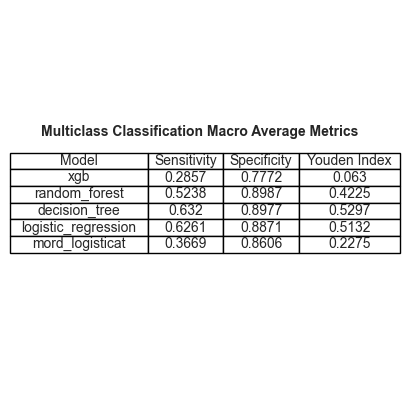

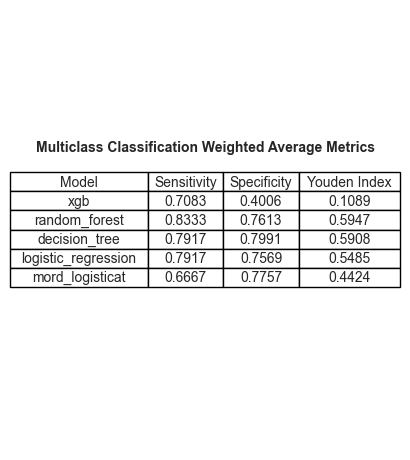

In [23]:
from utils.plotting_helper import display_multiclass_model_metrics

display_multiclass_model_metrics(optimized_model_runs)

In [24]:
best_youden = (None, 0)

for model_name, model in optimized_models.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    stats = EDA.multiclass_metrics(
        confusion_matrix(
            y_val_temp,
            model.fit(X_train_temp, y_train_temp).predict(X_val_temp)
        ),
        labels="DPN_Status", verbosity=1)

    print(f"Statistics for optimized {model_name} model")
    best_youden = (model_name, stats['weighted_avg']['youden_index']) if stats['weighted_avg']['youden_index'] > best_youden[1] else best_youden
    pprint(stats)
    
print(f"The best model is: {best_youden[0]} with a youden_index of {best_youden[1]}")

Macro-Averaged Metrics:
  Sensitivity (Macro) = 0.286
  Specificity (Macro) = 0.777
  Youden_index (Macro) = 0.063

Weighted-Averaged Metrics:
  Sensitivity (Weighted) = 0.708
  Specificity (Weighted) = 0.401
  Youden_index (Weighted) = 0.109

Statistics for optimized xgb model
{'macro_avg': {'sensitivity': 0.2857142857142857,
               'specificity': 0.7772357723577236,
               'youden_index': 0.06295005807200926},
 'per_class': {'sensitivity': [0.0, 0.0, 0.14285714285714285, 1.0],
               'specificity': [1.0,
                               1.0,
                               0.975609756097561,
                               0.13333333333333333],
               'support': [2, 6, 7, 33],
               'youden_index': [0.0,
                                0.0,
                                0.11846689895470375,
                                0.1333333333333333]},
 'weighted_avg': {'sensitivity': 0.7083333333333334,
                  'specificity': 0.400609756097561

### Generating Counterfactuals for Each Model

In [25]:
cf_explainers = {}

for model_name, model in optimized_models.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)
    
    X_temp = pd.concat([X_train_temp, X_val_temp], axis=0)
    y_temp = pd.concat([y_train_temp, y_val_temp], axis=0)

    df_temp = pd.concat([X_temp, y_temp], axis=1)
    
    model.fit(X_train_temp, y_train_temp)
    
    d = dice_ml.Data(dataframe=df_temp, continuous_features=df_temp.columns.drop('DPN_Status').tolist(), outcome_name='DPN_Status')
    m = dice_ml.Model(model=model, backend="sklearn", model_type="classifier")

    exp = dice_ml.Dice(d, m, method="genetic")

    print(f"generating counterfactuals for the {model_name} model")

    e1 = exp.generate_counterfactuals(
        X_val_temp, total_CFs=10, desired_class=3)

    cf_explainers[model_name] = e1

generating counterfactuals for the xgb model


100%|██████████| 48/48 [00:15<00:00,  3.17it/s]


generating counterfactuals for the random_forest model


100%|██████████| 48/48 [00:16<00:00,  3.00it/s]


generating counterfactuals for the decision_tree model


100%|██████████| 48/48 [00:12<00:00,  3.87it/s]


generating counterfactuals for the logistic_regression model


100%|██████████| 48/48 [00:12<00:00,  3.97it/s]


generating counterfactuals for the mord_logisticat model


100%|██████████| 48/48 [00:11<00:00,  4.15it/s]


In [26]:
# e1.visualize_as_dataframe()


--- Plotting ROC for the Best Multiclass Model decision_tree ---


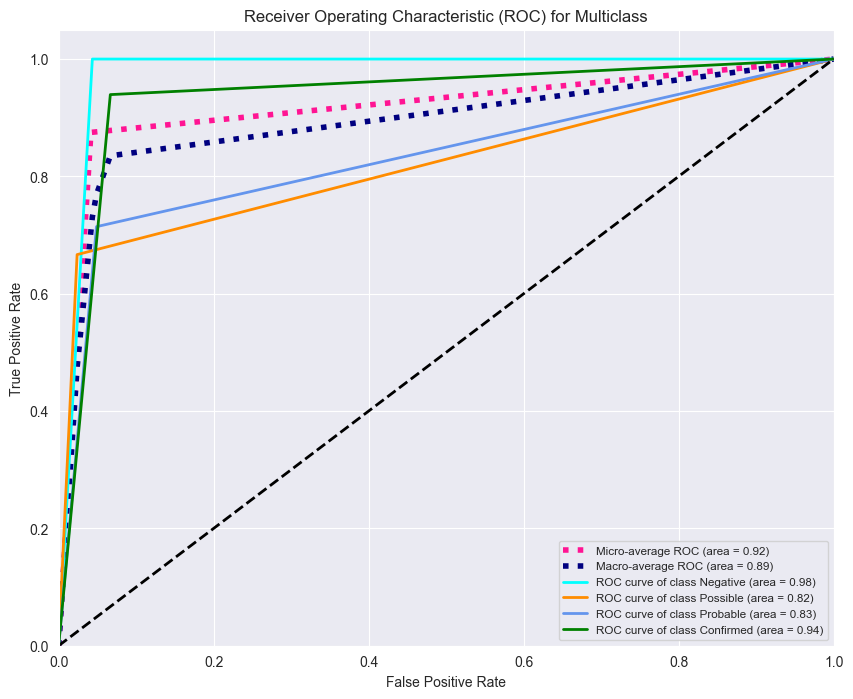

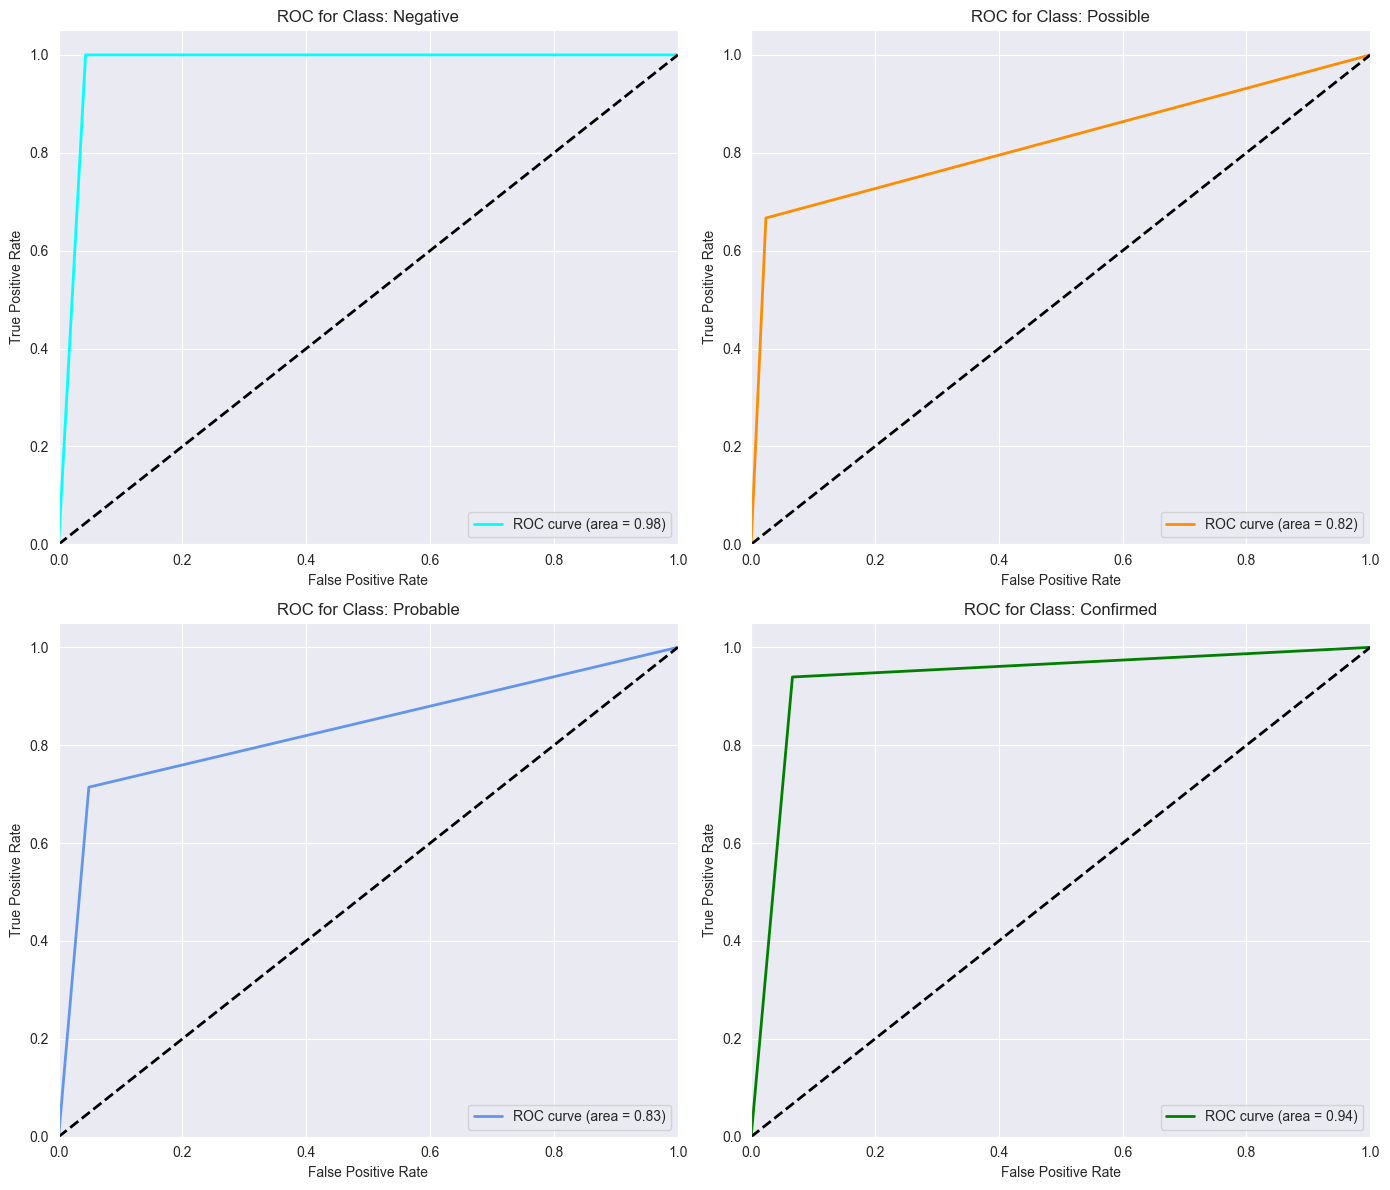

In [27]:
# Use the bets multiclass model to plot ROC curve and AUC graphs
best_multiclass_model = optimized_models[best_youden[0]]

X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(best_youden[0])

print(f"\n--- Plotting ROC for the Best Multiclass Model {best_youden[0]} ---")
EDA.plot_roc_multiclass_from_model(
    model=best_multiclass_model, # Replace with your actual multiclass model (e.g., mord.LogisticAT)
    X_val=X_val_temp, # Replace with your actual X_val for multiclass
    y_val=y_val_temp, # Replace with your actual y_val for multiclass
    class_names=['Negative', 'Possible', 'Probable', 'Confirmed'] # Your actual class names
)

🚀 Analyzing SHAP values for: xgb


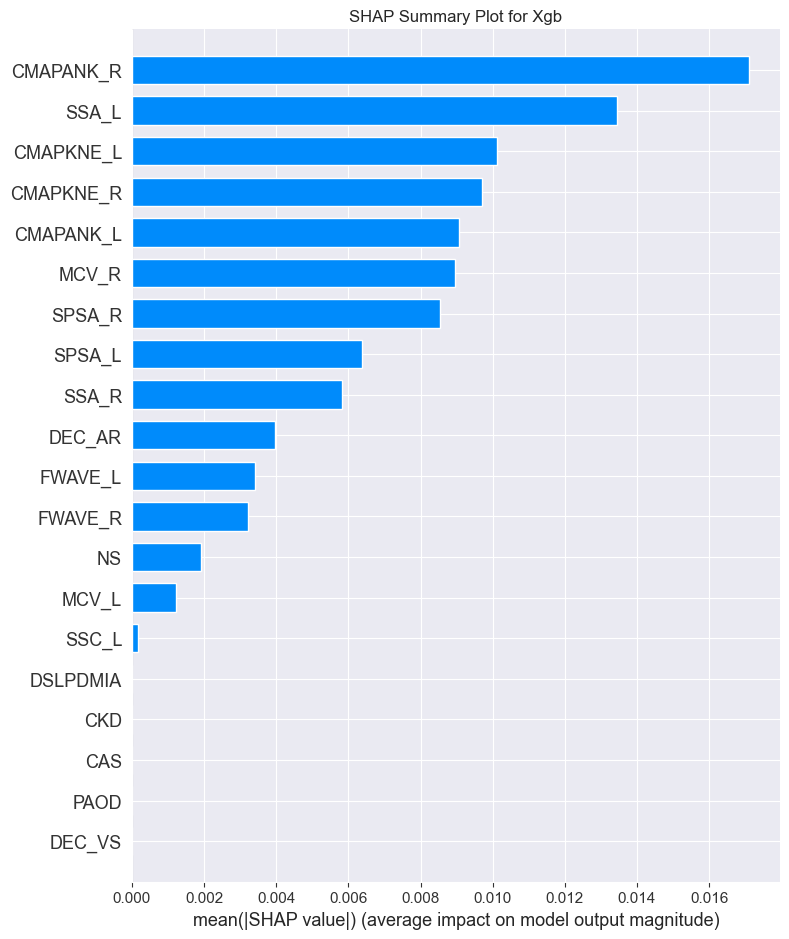

--------------------------------------------------
🚀 Analyzing SHAP values for: random_forest


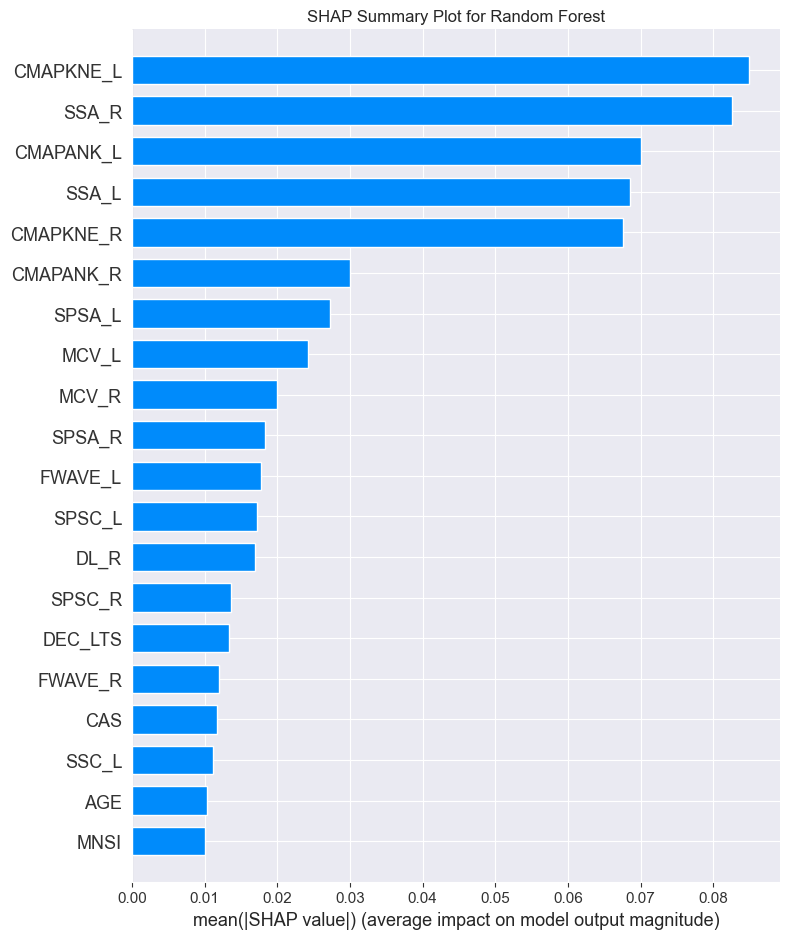

--------------------------------------------------
🚀 Analyzing SHAP values for: decision_tree


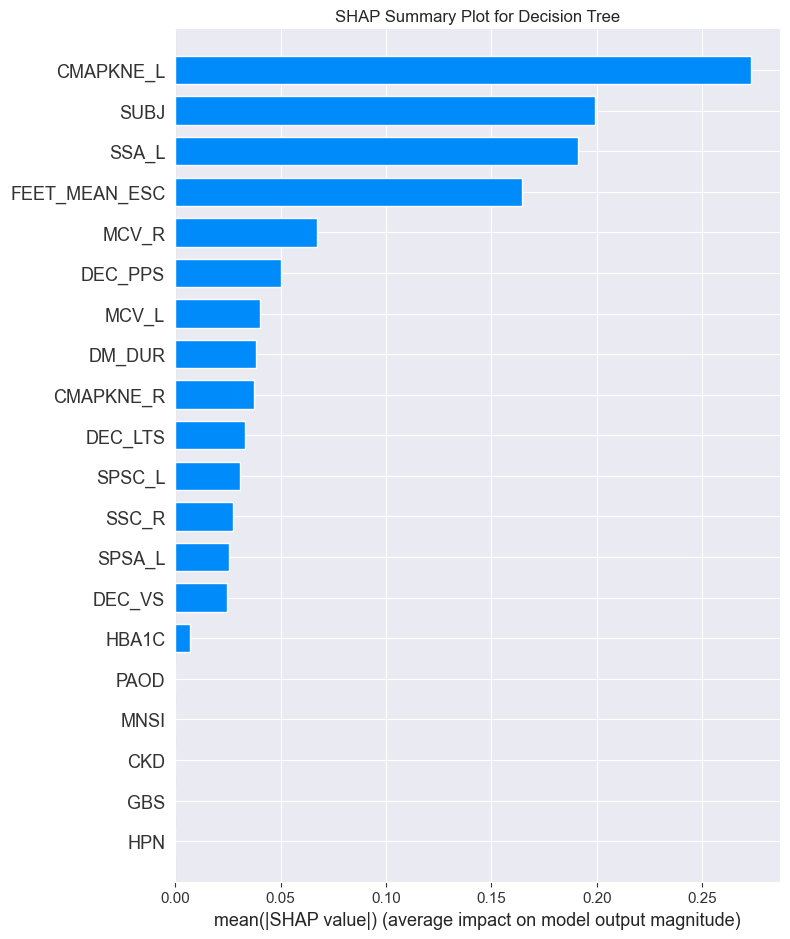

--------------------------------------------------
🚀 Analyzing SHAP values for: logistic_regression


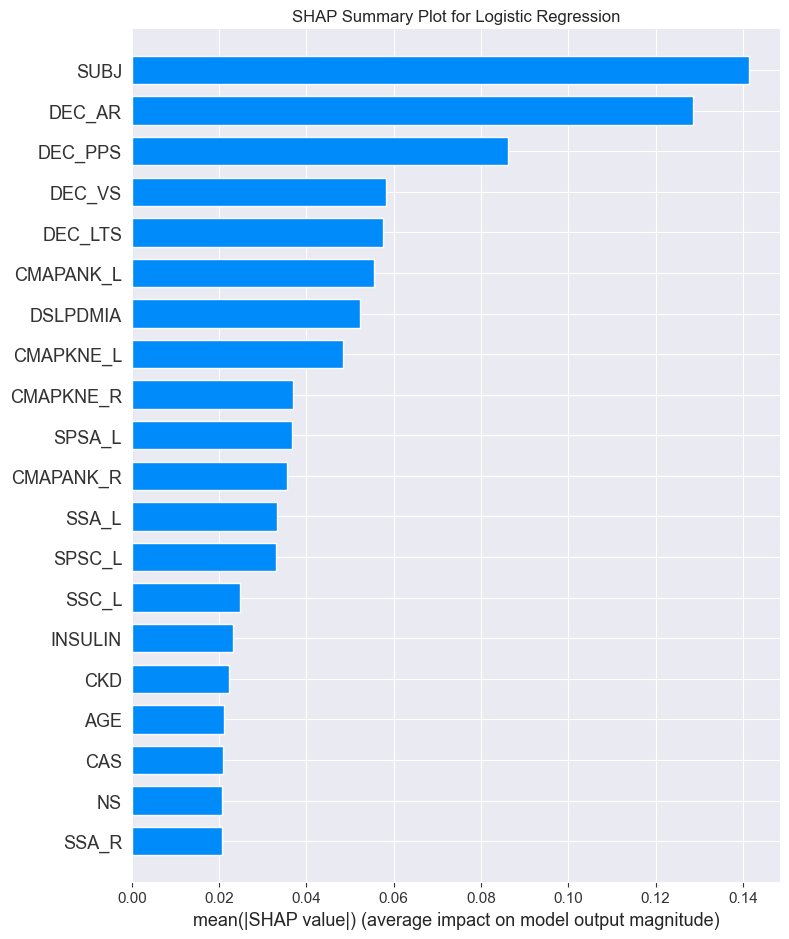

--------------------------------------------------
🚀 Analyzing SHAP values for: mord_logisticat


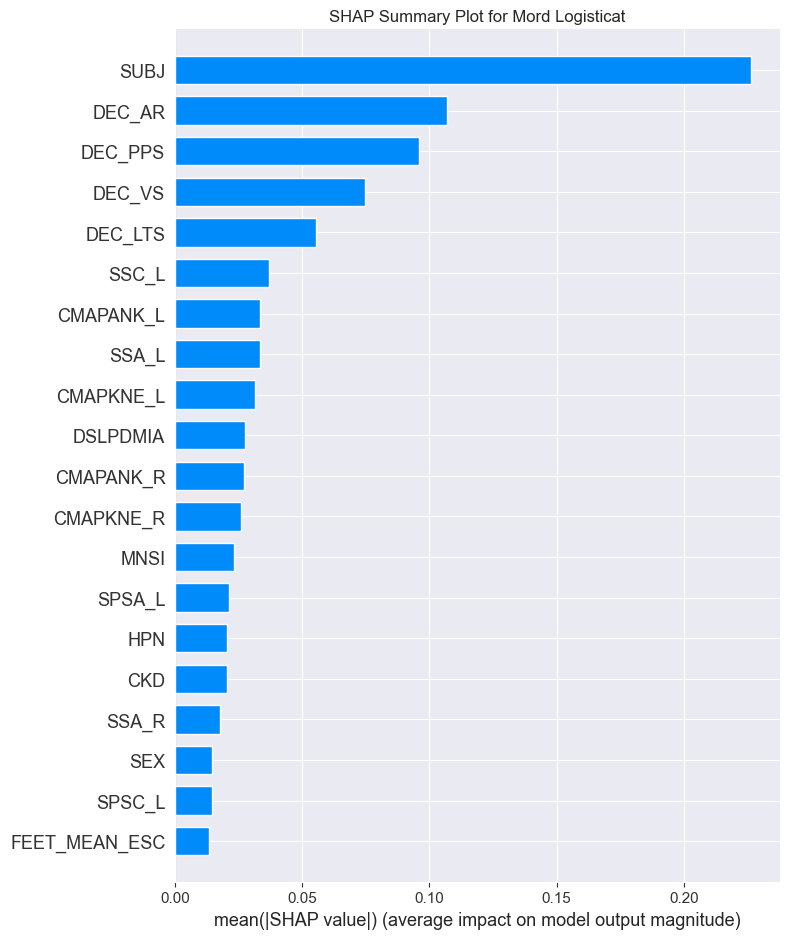

--------------------------------------------------


In [28]:
import shap

# --- Automated SHAP Analysis ---
for model_name, model in optimized_models.items():
    print(f"🚀 Analyzing SHAP values for: {model_name}")

    model.fit(X_train, y_train)

    # Define a simple predict function for the current model
    # This closure ensures 'model' refers to the correct model in each iteration
    def current_model_predict(X):
        # For classifiers, .predict_proba is often preferred for SHAP for better interpretability
        # especially for multi-class, but .predict is also valid.
        # We'll use .predict here as per your original request, but it's good to note.
        return model.predict(X)

    # Use a masker: your input DataFrame
    masker = shap.maskers.Independent(X_val)

    # Create explainer with custom predict function
    # Specify the masker for consistency
    explainer = shap.Explainer(current_model_predict, masker=masker)

    # Compute SHAP values
    shap_values = explainer(X_val)

    # Plot the summary plot for the current model
    # show=False prevents immediate display, allowing title to be set
    shap.summary_plot(shap_values, X_val, show=False, plot_type="bar")
    plt.title(f"SHAP Summary Plot for {model_name.replace('_', ' ').title()}")
    plt.tight_layout() # Adjust layout to prevent title overlap
    plt.show() # Display the plot for the current model
    print("-" * 50) # Separator for clarity


In [29]:
print(best_youden[0])

decision_tree


In [30]:
from utils.eval import DiceEvaluator

cf_stats_per_model = {}

for model_name, model in optimized_models.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(best_youden[0])

    X_temp = pd.concat([X_train_temp, X_val_temp], axis=0)
    y_temp = pd.concat([y_train_temp, y_val_temp], axis=0)
    
    df_temp = pd.concat([X_temp, y_temp], axis=1)
    
    model.fit(X_train_temp, y_train_temp)

    cf_explainer = cf_explainers[model_name]

    # Instantiate the evaluator
    evaluator = DiceEvaluator(cf_explainer, df_temp)
    
    cf_stats_per_model[model_name] = evaluator.get_stats(df_temp, 'multiclass', verbosity=0)

TypeError: DiceEvaluator._feasibility() takes 2 positional arguments but 3 were given

In [ ]:
pprint(cf_stats_per_model)

In [ ]:
from utils.plotting_helper import display_cf_metrics

display_cf_metrics(cf_stats_per_model)